# 可视化训练日志-训练过程总体评估指标

训练模型时在`work_dirs`目录生成记录训练日志，解析其中损失函数、评估指标等信息，并可视化。

同济子豪兄：https://space.bilibili.com/1900783

## 设置Matplotlib中文字体

In [1]:
# # windows操作系统
# plt.rcParams['font.sans-serif']=['SimHei']  # 用来正常显示中文标签 
# plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号

In [2]:
# Mac操作系统，参考 https://www.ngui.cc/51cto/show-727683.html
# 下载 simhei.ttf 字体文件
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf

In [1]:
# Linux操作系统，例如 云GPU平台：https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1
# 如果遇到 SSL 相关报错，重新运行本代码块即可
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O /environment/miniconda3/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf
# !rm -rf /home/featurize/.cache/matplotlib

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体


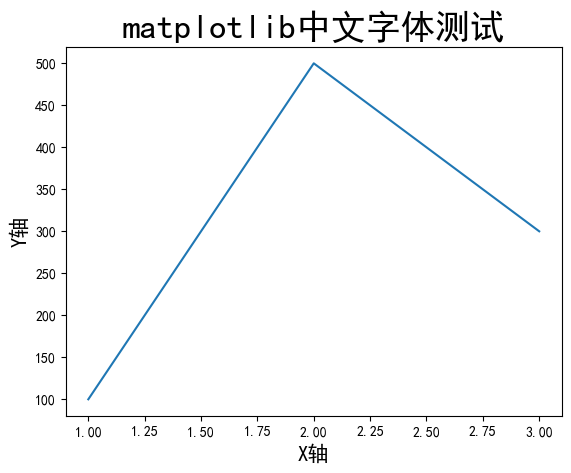

In [2]:
plt.plot([1,2,3], [100,500,300])
plt.title('matplotlib中文字体测试', fontsize=25)
plt.xlabel('X轴', fontsize=15)
plt.ylabel('Y轴', fontsize=15)
plt.show()

## 进入MMSegmentation主目录

In [3]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_custom_data/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_custom_data\mmsegmentation-main


In [2]:
os.getcwd()

'E:\\bishe_demo\\mmsegmentation-main'

## 导入工具包

In [4]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

## 载入训练日志

In [5]:
# 日志文件路径
log_path = './work_dirs/ZihaoDataset-PSPNet/20250318_144754/vis_data/scalars.json'

In [6]:
with open(log_path, "r") as f:
    json_list = f.readlines()

In [7]:
len(json_list)

550

In [8]:
eval(json_list[4])

{'lr': 0.009994542389608127,
 'data_time': 0.18232061862945556,
 'loss': 1.9283409357070922,
 'decode.loss_ce': 1.4137434363365173,
 'decode.acc_seg': 47.203826904296875,
 'aux.loss_ce': 0.5145975083112717,
 'aux.acc_seg': 57.047176361083984,
 'time': 1.0664781332015991,
 'iter': 50,
 'memory': 4815,
 'step': 50}

In [9]:
import pandas as pd

# 初始化空的 DataFrame
df_train = pd.DataFrame()
df_test = pd.DataFrame()

# 遍历 json_list
for each in json_list[:-1]:
    # 将字符串转换为字典
    data = eval(each)
    
    # 根据条件将数据添加到 df_train 或 df_test
    if 'aAcc' in data:
        df_test = pd.concat([df_test, pd.DataFrame([data])], ignore_index=True)
    else:
        df_train = pd.concat([df_train, pd.DataFrame([data])], ignore_index=True)

In [10]:
df_train

,lr,data_time,loss,decode.loss_ce,decode.acc_seg,aux.loss_ce,aux.acc_seg,time,iter,memory,step
0,0.009999,0.006238,1.956044,1.397935,61.303043,0.558110,61.303043,1.940324,10,6481,10
1,0.009998,0.200523,1.894272,1.361923,45.673466,0.532349,45.673847,1.078746,20,4815,20
2,0.009997,0.197718,1.654836,1.180269,69.814301,0.474567,77.439499,1.073321,30,4815,30
3,0.009996,0.170344,1.480577,1.023907,63.844872,0.456669,63.235474,1.043905,40,4815,40
4,0.009995,0.182321,1.928341,1.413743,47.203827,0.514598,57.047176,1.066478,50,4815,50
...,...,...,...,...,...,...,...,...,...,...,...
495,0.009446,0.175969,0.244072,0.127842,84.146973,0.116230,75.635529,1.082845,4960,4816,4960
496,0.009445,0.182669,0.323009,0.192642,93.859192,0.130367,93.380829,1.091721,4970,4816,4970
497,0.009444,0.174061,0.268060,0.150783,93.510147,0.117277,93.067261,1.085523,4980,4818,4980
498,0.009443,0.177631,0.281222,0.146502,92.551132,0.134720,88.079926,1.088114,4990,4816,4990


In [11]:
df_test

,aAcc,mIoU,mAcc,mDice,mFscore,mPrecision,mRecall,data_time,time,step
0,78.62,28.00,36.35,36.82,36.82,57.23,36.35,0.178251,5.450184,100
1,78.42,23.95,30.97,31.48,39.35,37.93,30.97,0.004669,0.656010,200
2,79.71,26.85,33.01,36.63,36.63,54.13,33.01,0.003595,0.650409,300
3,74.34,35.89,53.52,49.88,49.88,52.76,53.52,0.003927,0.653803,400
4,73.02,28.40,40.38,39.19,39.19,44.31,40.38,0.003777,0.650280,500
5,78.78,31.05,45.92,41.89,41.89,52.43,45.92,0.003284,0.654118,600
6,81.59,37.42,60.19,50.74,50.74,65.40,60.19,0.004246,0.652256,700
7,77.92,41.09,71.23,55.81,55.81,50.54,71.23,0.004197,0.655359,800
8,72.34,21.81,35.03,28.35,28.35,36.63,35.03,0.002678,0.650644,900
9,79.14,45.50,67.90,60.95,60.95,57.95,67.90,0.002610,0.651232,1000


## 导出训练日志表格

In [12]:
df_train.to_csv('图表/训练日志-训练集.csv', index=False)
df_test.to_csv('图表/训练日志-测试集.csv', index=False)

## 可视化辅助函数

In [13]:
from matplotlib import colors as mcolors
import random
random.seed(124)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'black', 'indianred', 'brown', 'firebrick', 'maroon', 'darkred', 'red', 'sienna', 'chocolate', 'yellow', 'olivedrab', 'yellowgreen', 'darkolivegreen', 'forestgreen', 'limegreen', 'darkgreen', 'green', 'lime', 'seagreen', 'mediumseagreen', 'darkslategray', 'darkslategrey', 'teal', 'darkcyan', 'dodgerblue', 'navy', 'darkblue', 'mediumblue', 'blue', 'slateblue', 'darkslateblue', 'mediumslateblue', 'mediumpurple', 'rebeccapurple', 'blueviolet', 'indigo', 'darkorchid', 'darkviolet', 'mediumorchid', 'purple', 'darkmagenta', 'fuchsia', 'magenta', 'orchid', 'mediumvioletred', 'deeppink', 'hotpink']
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",0,1,2,3,4,5,6,7,8,9,10,11]
linestyle = ['--', '-.', '-']

def get_line_arg():
    '''
    随机产生一种绘图线型
    '''
    line_arg = {}
    line_arg['color'] = random.choice(colors)
    # line_arg['marker'] = random.choice(markers)
    line_arg['linestyle'] = random.choice(linestyle)
    line_arg['linewidth'] = random.randint(1, 4)
    # line_arg['markersize'] = random.randint(3, 5)
    return line_arg

## 训练集损失函数

In [14]:
metrics = ['loss', 'decode.loss_ce', 'aux.loss_ce']

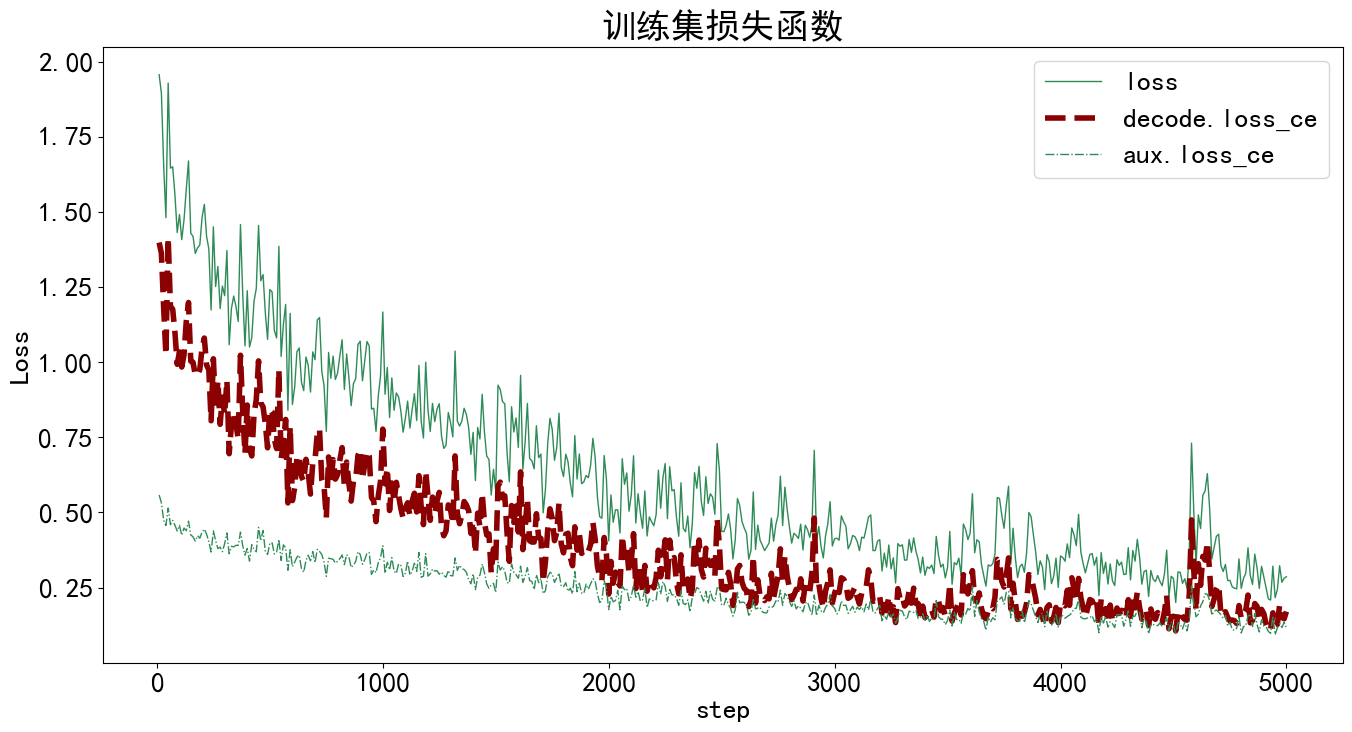

In [15]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.title('训练集损失函数', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集损失函数.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 训练集准确率

In [16]:
metrics = ['decode.acc_seg', 'aux.acc_seg']

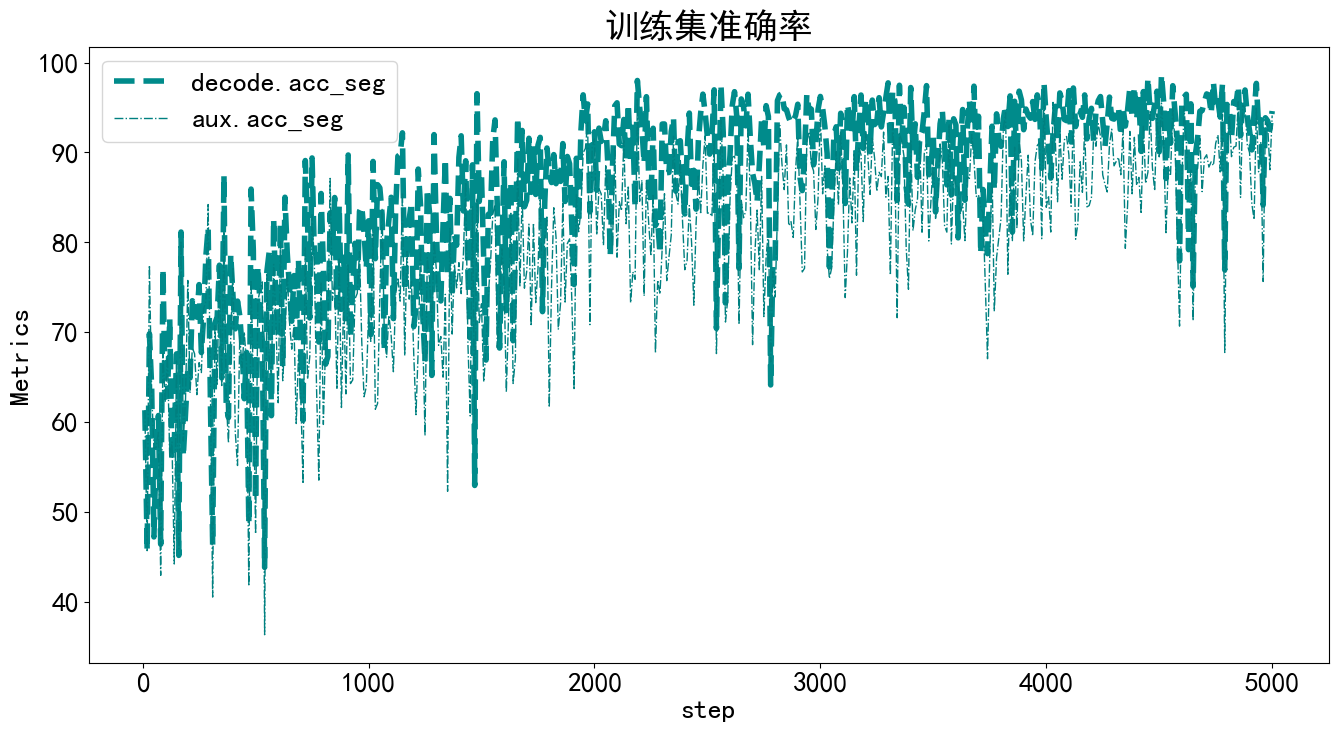

In [17]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('训练集准确率', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集准确率.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 测试集评估指标

In [18]:
df_test.columns

Index(['aAcc', 'mIoU', 'mAcc', 'mDice', 'mFscore', 'mPrecision', 'mRecall',
       'data_time', 'time', 'step'],
      dtype='object')

In [19]:
metrics = ['aAcc', 'mIoU', 'mAcc', 'mDice', 'mFscore', 'mPrecision', 'mRecall']

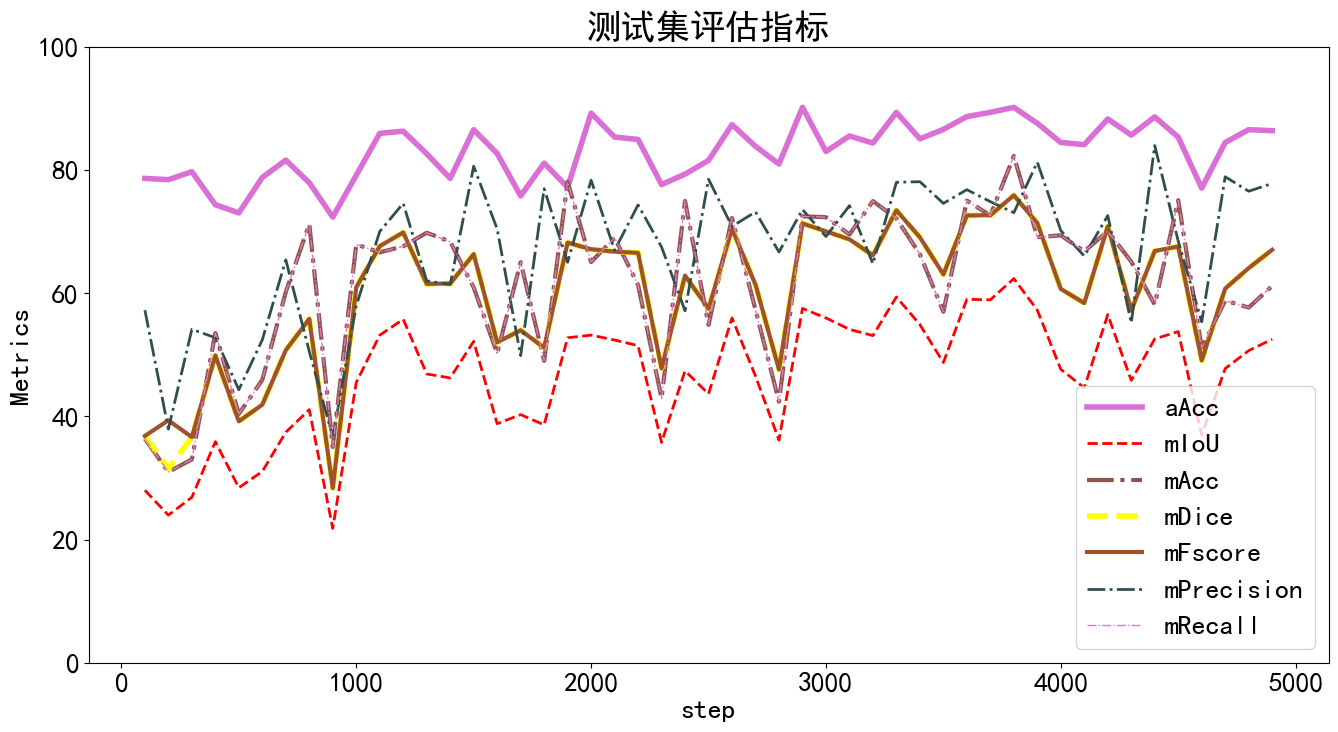

In [20]:
plt.figure(figsize=(16, 8))

x = df_test['step']
for y in metrics:
    try:
        plt.plot(x, df_test[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.ylim([0, 100])
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('测试集评估指标', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/测试集分类评估指标.pdf', dpi=120, bbox_inches='tight')

plt.show()